# Football Transfer Value: Exploratory Data Analysis (EDA)
This notebook contains our initial data exploration, focusing on descriptive statistics, missing values, correlation analysis, and PCA.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Use the correct relative paths
BASE_DIR = os.path.dirname(os.path.abspath(''))
DATA_DIR = os.path.join(BASE_DIR, 'data', 'raw')

In [2]:
print('Loading datasets...')
players_df = pd.read_csv(os.path.join(DATA_DIR, 'players_with_fifa.csv'), low_memory=False)
player_valuations_df = pd.read_csv(os.path.join(DATA_DIR, 'player_valuations.csv'), low_memory=False)

player_valuations_df['date'] = pd.to_datetime(player_valuations_df['date'])
players_df['date_of_birth'] = pd.to_datetime(players_df['date_of_birth'], errors='coerce')

player_valuations_df = player_valuations_df.sort_values(by=['player_id', 'date'])
target_df = player_valuations_df.groupby('player_id').last().reset_index()
target_df = target_df.rename(columns={'date': 'valuation_date', 'market_value_in_eur': 'target_market_value'})

df = players_df.merge(target_df[['player_id', 'valuation_date', 'target_market_value']], on='player_id', how='inner')

df['age_at_valuation'] = (df['valuation_date'] - df['date_of_birth']).dt.days / 365.25
df['fifa_overall'] = df['fifa_overall'].fillna(df['fifa_overall'].median())
df['fifa_potential'] = df['fifa_potential'].fillna(df['fifa_overall'])
df['height_in_cm'] = df['height_in_cm'].fillna(df['height_in_cm'].median())

num_cols = ['target_market_value', 'age_at_valuation', 'height_in_cm', 'fifa_overall', 'fifa_potential', 'fifa_reputation']
df = df[num_cols].dropna()
df.head()

Loading datasets...


,target_market_value,age_at_valuation,height_in_cm,fifa_overall,fifa_potential,fifa_reputation
0,1000000,37.571526,184.0,81.0,81.0,4.0
1,750000,37.393566,190.0,77.0,77.0,2.0
2,1000000,35.389459,183.0,81.0,81.0,3.0
4,100000,37.215606,194.0,74.0,74.0,2.0
7,350000,36.681725,179.0,79.0,79.0,2.0


## Correlation Analysis
Understanding linear relationships between variables.

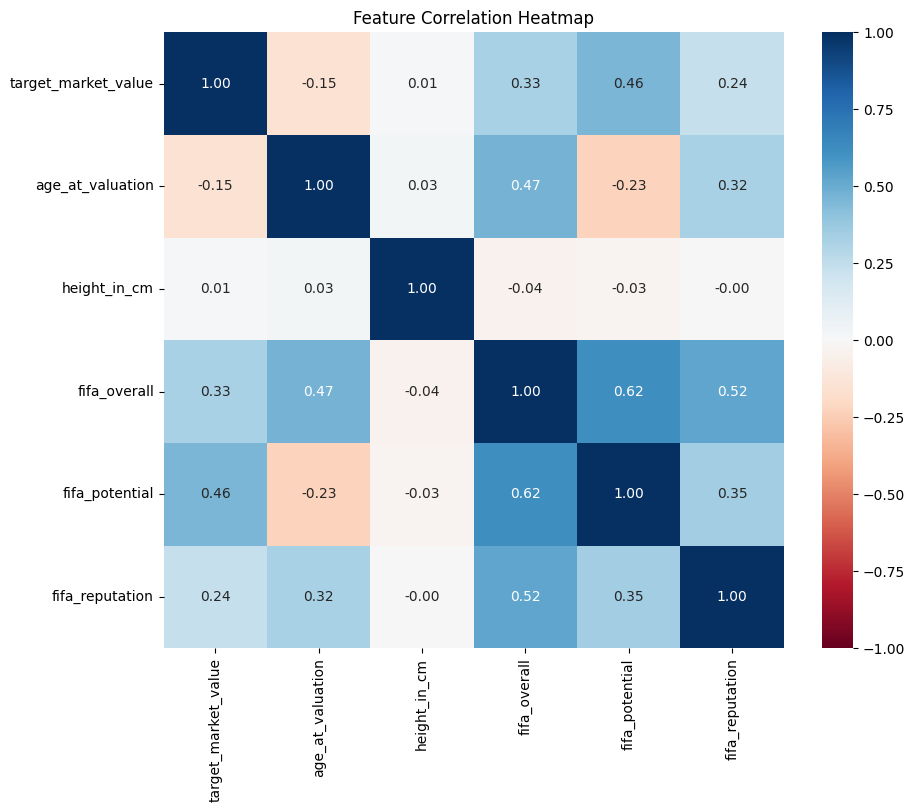

In [3]:
corr = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu', fmt='.2f', vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

## Target Variable Distribution
Transfer values are highly skewed, so we apply a logarithmic transformation.

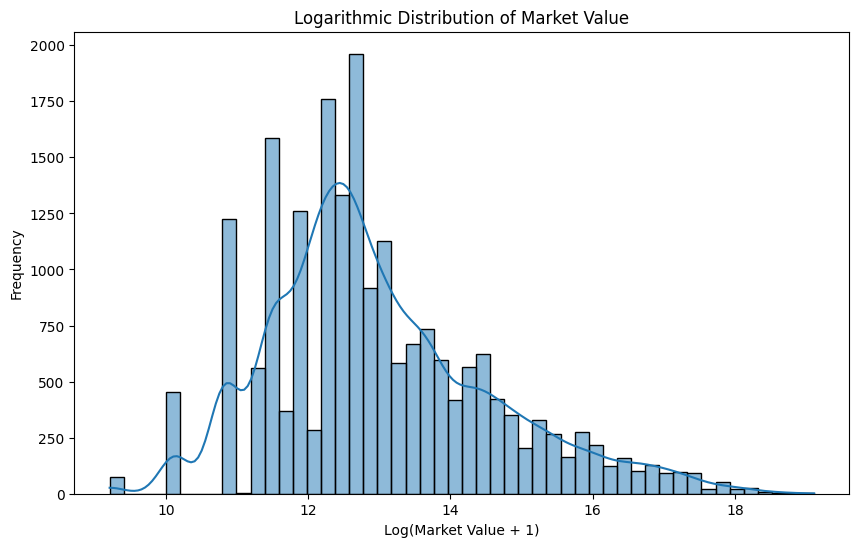

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df['target_market_value']), kde=True, bins=50)
plt.title('Logarithmic Distribution of Market Value')
plt.xlabel('Log(Market Value + 1)')
plt.ylabel('Frequency')
plt.show()

## Principal Component Analysis (PCA)
Evaluating how many components are needed to explain the variance in the data.

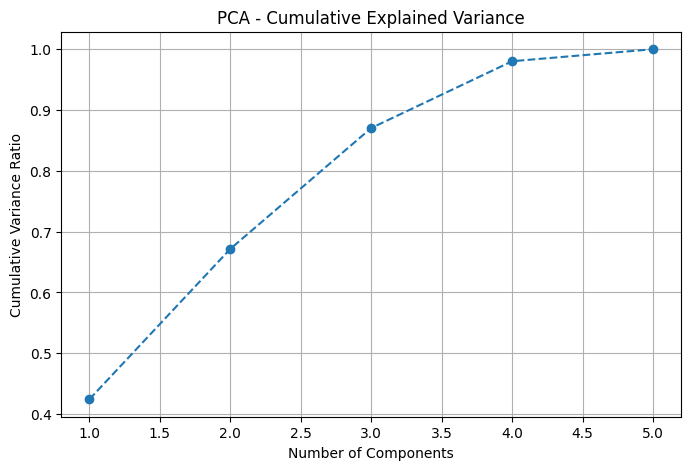

In [5]:
X = df.drop(columns=['target_market_value'])
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('PCA - Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Ratio')
plt.grid(True)
plt.show()

## Age vs. Market Value (Non-Linearity)
This plot justifies our choice of a tree-based model (Gradient Boosting) over Linear Regression. We can clearly see a peak around the mid-20s, after which value decays.

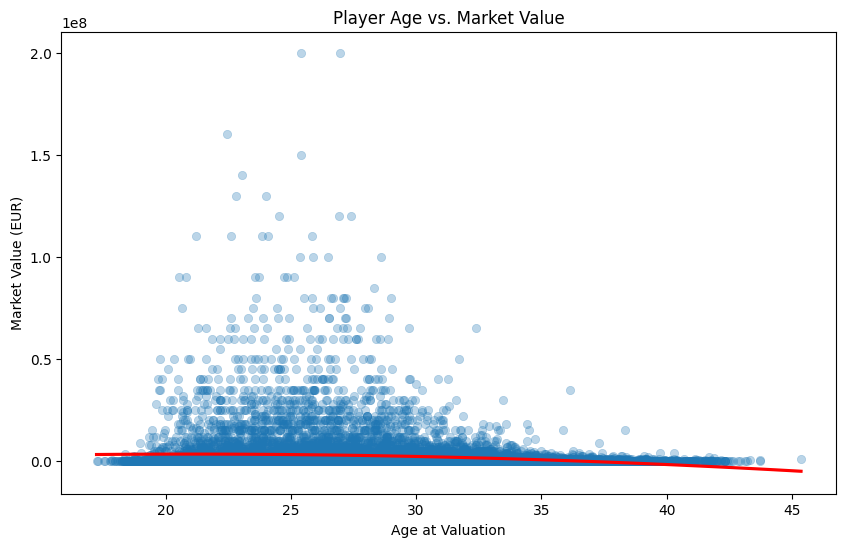

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age_at_valuation', y='target_market_value', data=df, alpha=0.3, edgecolor=None)
# Adding a trendline to make the curve obvious
sns.regplot(x='age_at_valuation', y='target_market_value', data=df, scatter=False, order=2, color='red')
plt.title('Player Age vs. Market Value')
plt.xlabel('Age at Valuation')
plt.ylabel('Market Value (EUR)')
plt.show()

## FIFA Overall vs Market Value
Checking how well the video game ratings correlate with real-world valuations.

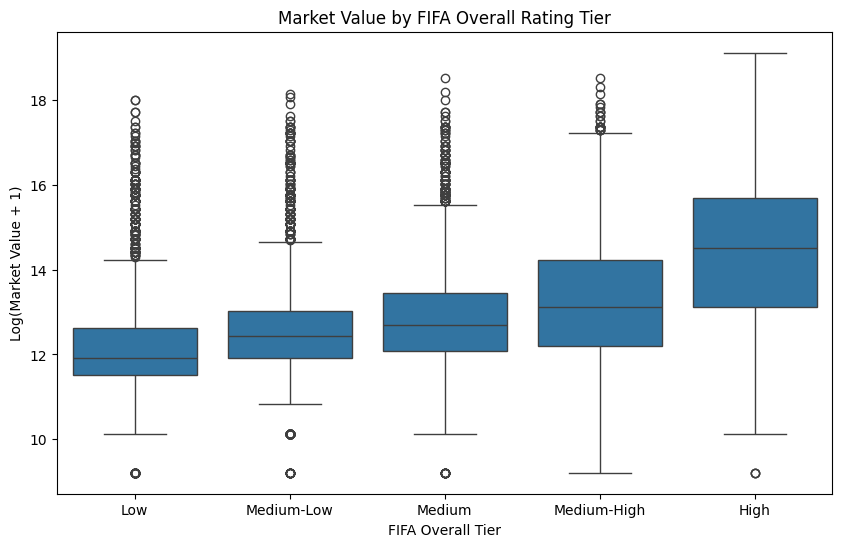

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=pd.qcut(df['fifa_overall'], q=5, labels=['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High']), 
            y=np.log1p(df['target_market_value']))
plt.title('Market Value by FIFA Overall Rating Tier')
plt.xlabel('FIFA Overall Tier')
plt.ylabel('Log(Market Value + 1)')
plt.show()